In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import pickle

In [5]:
data_dir = "../dataset"
x_list = []
y_list = []
batch_size = 32

In [6]:
for file in os.listdir(data_dir):
    path = os.path.join(data_dir, file)
    with open(path, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')

        x_list.append(data_dict[b'data'])
        y_list.extend(data_dict[b'labels'])

C:\Users\xavif\AppData\Local\Temp\ipykernel_14600\250140131.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(fo, encoding='bytes')


In [7]:
X = np.concatenate(x_list)
Y = np.array(y_list)

In [8]:
X = X.reshape(-1, 3,32,32)
X = X.transpose(0,2,3,1)
X = X.astype(float) / 255.0

In [9]:
y = to_categorical(Y, 10)

In [10]:
dataset = tf.data.Dataset.from_tensor_slices((X, y))

dataset = dataset.shuffle(buffer_size=len(X), seed=42)

In [11]:
train_size = int(0.8*len(X))

In [12]:
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

In [13]:
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [14]:
print(len(X), X.shape)
print(len(y), y.shape if isinstance(y, np.ndarray) else 'no es ndarray')

50000 (50000, 32, 32, 3)
50000 (50000, 10)


In [15]:
IMG_SIZE = (32,32) + (3,)

In [16]:
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE, include_top=False, weights='imagenet')

C:\Users\xavif\AppData\Local\Temp\ipykernel_14600\846687965.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE, include_top=False, weights='imagenet')


In [ ]:
base_model.summary()

# Congelación de capas

In [18]:
base_model.trainable = True

In [19]:
for layer in base_model.layers[:50]:
    layer.trainable = False

In [20]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x= layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(10, activation='softmax')(x)

In [21]:
model = models.Model(inputs=base_model.input, outputs=output)

In [22]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_dataset, 
    validation_data=val_dataset,
    epochs=10

)

Epoch 1/10


c:\Users\xavif\Documents\MASTER\MobileNet-TransferLearning\.venv\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1172: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 135s 94ms/step - accuracy: 0.5394 - loss: 1.3596 - val_accuracy: 0.4610 - val_loss: 2.1038
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.6694 - loss: 1.0033 - val_accuracy: 0.5801 - val_loss: 1.6599
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.7086 - loss: 0.8928 - val_accuracy: 0.6086 - val_loss: 1.3323
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 259s 207ms/step - accuracy: 0.7325 - loss: 0.8173 - val_accuracy: 0.6811 - val_loss: 1.1688
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 119s 95ms/step - accuracy: 0.7486 - loss: 0.7625 - val_accuracy: 0.7585 - val_loss: 0.8314
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 98ms/step - accuracy: 0.7615 - loss: 0.7214 - val_accuracy: 0.7926 - val_loss: 0.6998
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 130s 104ms/step - accuracy: 0.7778 - loss: 0.6715 - val_accuracy: 0.7890 - val_loss: 0.6943
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 118s 95ms/step - accuracy: 0.7910 - 

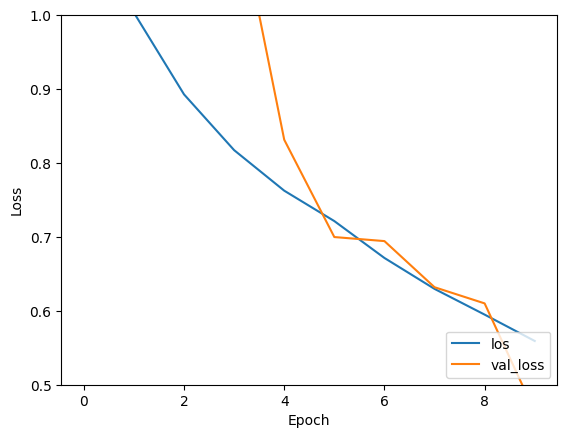

In [26]:
plt.plot(history.history['loss'], label='los')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.5, 1)
plt.legend(loc='lower right')
plt.savefig("./image4.png")

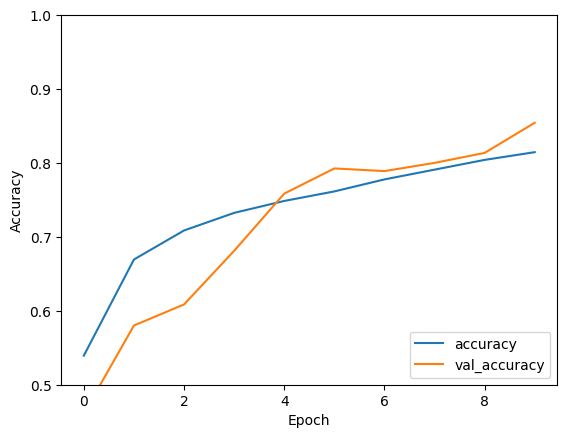

In [25]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1)
plt.legend(loc='lower right')
plt.savefig("./image3.png")